<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-03-09 10:49:46--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  37.4MB/s    in 5.4s    

2026-03-09 10:49:52 (37.1 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

In [4]:
!pip install matplotlib

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [6]:
conn = sqlite3.connect('survey-data.sqlite')

In [10]:
# exported data to csv so I can have a better understanding of said data (not relevent to lab)
QUERY = "SELECT * FROM main"
df_all_data = pd.read_sql_query(QUERY, conn)
df_all_data.to_csv('survey_results_export.csv', index=False)



## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [7]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [ ]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


**Demo 3: Group data by age**


In [ ]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


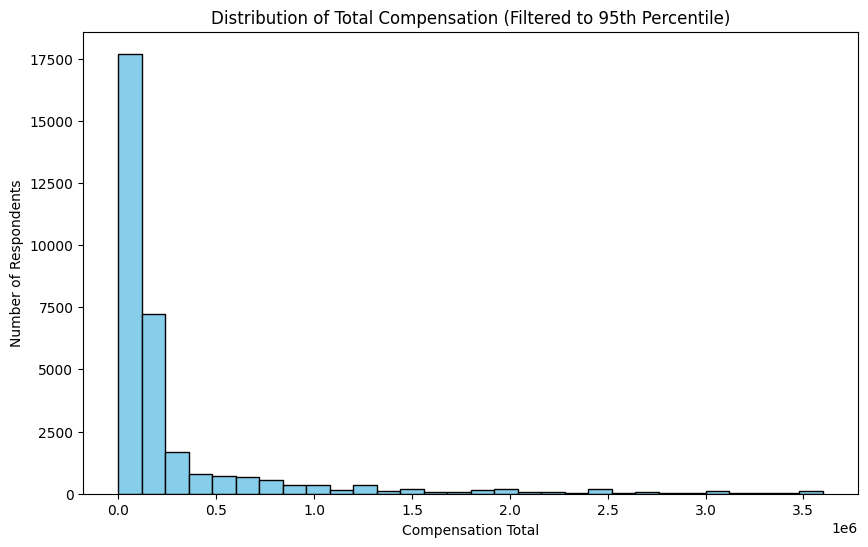

In [14]:
# why must you add these stupid outliers to all the data that just waste my time in trying to fix, if I did not download the csv file I would be so confused :(
upper_limit = df['CompTotal'].quantile(0.95)
df_filtered = df[df['CompTotal'] <= upper_limit]
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['CompTotal'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Compensation (Filtered to 95th Percentile)')
plt.xlabel('Compensation Total')
plt.ylabel('Number of Respondents')
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


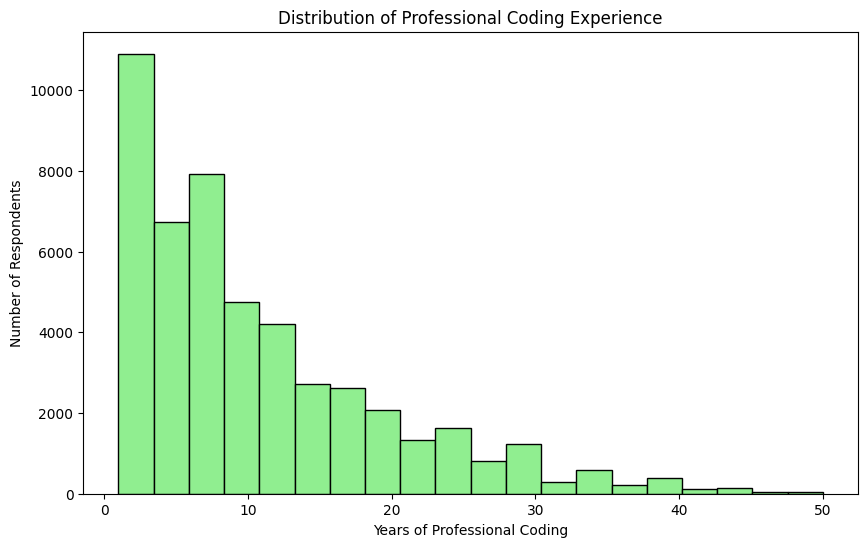

In [15]:
QUERY = "SELECT YearsCodePro FROM main"
df_ycp = pd.read_sql_query(QUERY, conn)
plt.figure(figsize=(10, 6))
plt.hist(pd.to_numeric(df_ycp['YearsCodePro'], errors='coerce').dropna(), bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of Professional Coding Experience')
plt.xlabel('Years of Professional Coding')
plt.ylabel('Number of Respondents')
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


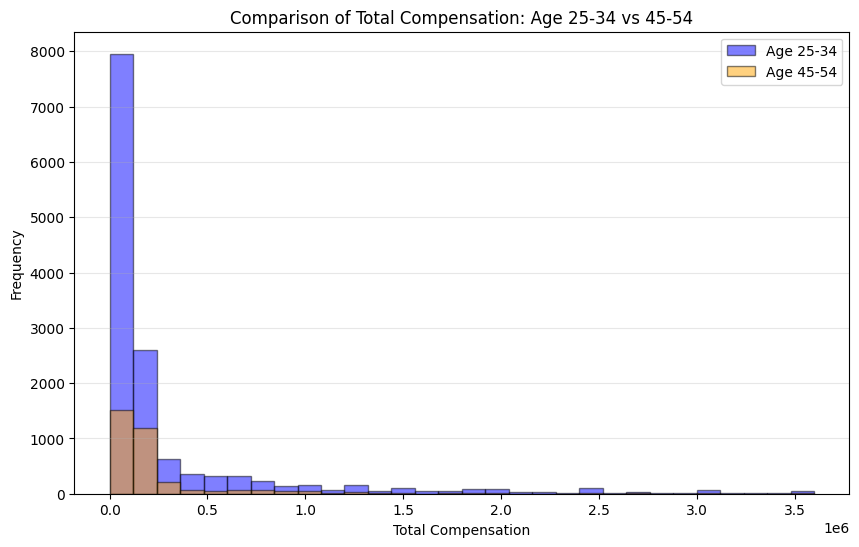

In [17]:
QUERY = "SELECT Age, CompTotal FROM main"
df_age_comp = pd.read_sql_query(QUERY, conn)
upper_limit = df_age_comp['CompTotal'].quantile(0.95)
age_25_34 = df_age_comp[df_age_comp['Age'] == '25-34 years old']['CompTotal'].dropna()
age_45_54 = df_age_comp[df_age_comp['Age'] == '45-54 years old']['CompTotal'].dropna()
age_25_34_filtered = age_25_34[age_25_34 <= upper_limit]
age_45_54_filtered = age_45_54[age_45_54 <= upper_limit]
plt.figure(figsize=(10, 6))
plt.hist(age_25_34_filtered, bins=30, alpha=0.5, label='Age 25-34', color='blue', edgecolor='black')
plt.hist(age_45_54_filtered, bins=30, alpha=0.5, label='Age 45-54', color='orange', edgecolor='black')
plt.title('Comparison of Total Compensation: Age 25-34 vs 45-54')
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


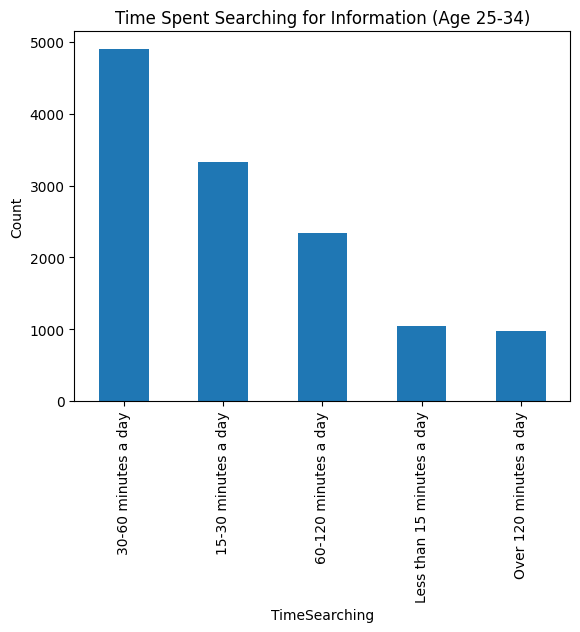

In [18]:
QUERY = "SELECT Age, TimeSearching FROM main"
df_search = pd.read_sql_query(QUERY, conn)
df_search[df_search['Age'] == '25-34 years old']['TimeSearching'].value_counts().plot(kind='bar')
plt.title('Time Spent Searching for Information (Age 25-34)')
plt.ylabel('Count')
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


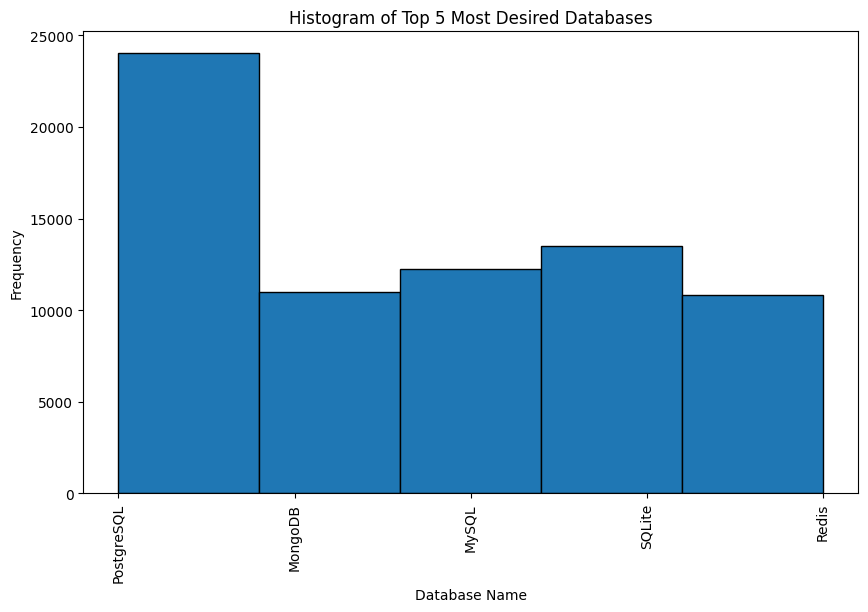

In [28]:
QUERY = "SELECT DatabaseWantToWorkWith FROM main"
df_db = pd.read_sql_query(QUERY, conn)
db_series = df_db['DatabaseWantToWorkWith'].dropna().str.split(';').explode()
top_5_names = db_series.value_counts().head(5).index.tolist()
db_filtered = db_series[db_series.isin(top_5_names)]
plt.figure(figsize=(10, 6))
plt.hist(db_filtered, bins=len(top_5_names), edgecolor='black')
plt.title('Histogram of Top 5 Most Desired Databases')
plt.xlabel('Database Name')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


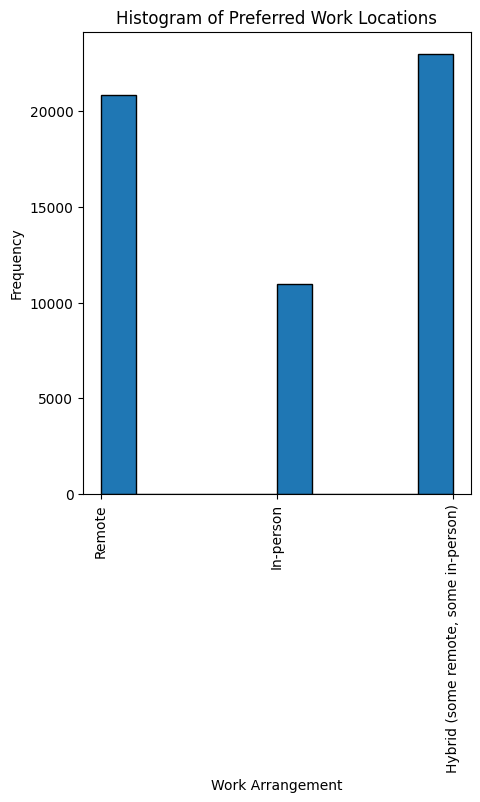

In [29]:
QUERY = "SELECT RemoteWork FROM main"
df_remote = pd.read_sql_query(QUERY, conn)
plt.figure(figsize=(5, 6))
plt.hist(df_remote['RemoteWork'].dropna(), edgecolor='black')
plt.title('Histogram of Preferred Work Locations')
plt.xlabel('Work Arrangement')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


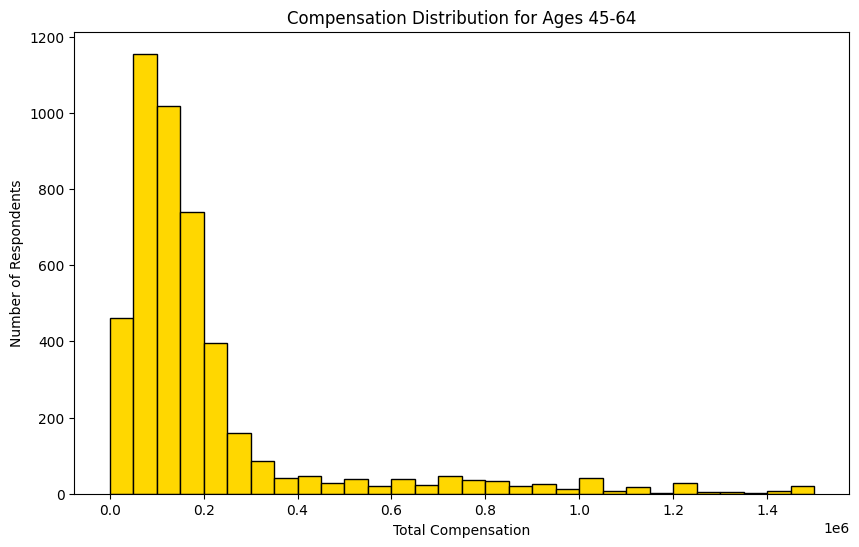

In [30]:
QUERY = """
SELECT CompTotal 
FROM main 
WHERE Age IN ('45-54 years old', '55-64 years old')
"""
df_mid = pd.read_sql_query(QUERY, conn)
upper_limit = df_mid['CompTotal'].quantile(0.95)
df_filtered = df_mid[df_mid['CompTotal'] <= upper_limit]
plt.figure(figsize=(10, 6))
plt.hist(df_filtered['CompTotal'].dropna(), bins=30, color='gold', edgecolor='black')
plt.title('Compensation Distribution for Ages 45-64')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


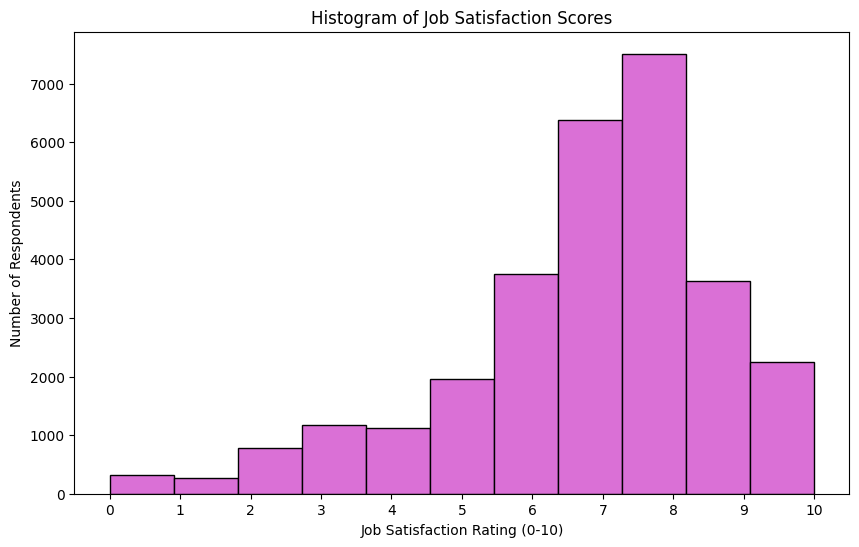

In [31]:
QUERY = "SELECT JobSat, YearsCodePro FROM main"
df_jobsat = pd.read_sql_query(QUERY, conn)
df_jobsat['YearsCodePro'] = pd.to_numeric(df_jobsat['YearsCodePro'], errors='coerce')
plt.figure(figsize=(10, 6))
plt.hist(df_jobsat['JobSat'].dropna(), bins=11, range=(0,10), color='orchid', edgecolor='black')
plt.title('Histogram of Job Satisfaction Scores')
plt.xlabel('Job Satisfaction Rating (0-10)')
plt.ylabel('Number of Respondents')
plt.xticks(range(11))
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [ ]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
